In [1]:
import pandas as pd
import numpy as np

# Ziarno losowości, żebyśmy mieli te same wyniki na naszych komputerach
np.random.seed(42)

liczba_klientow = 1000

# Generowanie cech
wiek = np.random.randint(18, 70, liczba_klientow)
miesieczny_rachunek = np.random.uniform(20, 200, liczba_klientow)
miesiace_z_nami = np.random.randint(1, 60, liczba_klientow)
liczba_telefonow_do_supportu = np.random.randint(0, 6, liczba_klientow)

# Obliczanie ryzyka odejścia (im wyższy wynik, tym gorzej)
ryzyko = (miesieczny_rachunek * 0.01) + (liczba_telefonow_do_supportu * 0.6) - (miesiace_z_nami * 0.04)

# Przekształcenie ryzyka na prawdopodobieństwo od 0 do 1 (tzw. funkcja sigmoidalna)
prawdopodobienstwo = 1 / (1 + np.exp(-ryzyko))

# Przypisanie 1 (Odszedł) lub 0 (Został) - losowanie z uwzględnieniem prawdopodobieństwa
odszedl = (np.random.rand(liczba_klientow) < prawdopodobienstwo).astype(int)

# Tworzenie naszego DataFrame
df_churn = pd.DataFrame({
    'Wiek': wiek,
    'Miesieczny_rachunek': miesieczny_rachunek.round(2),
    'Miesiace_z_nami': miesiace_z_nami,
    'Liczba_telefonow_do_supportu': liczba_telefonow_do_supportu,
    'Odszedl': odszedl
})

# Wyświetlenie tabelki
display(df_churn.head())

# Sprawdzenie tzw. balansu klas
print("\nRozkład klasy docelowej:")
print(df_churn['Odszedl'].value_counts())

,Wiek,Miesieczny_rachunek,Miesiace_z_nami,Liczba_telefonow_do_supportu,Odszedl
0,56,115.87,28,0,1
1,69,63.64,51,0,0
2,46,68.46,40,2,1
3,32,87.91,54,3,1
4,60,23.61,5,4,1



Rozkład klasy docelowej:
Odszedl
1    755
0    245
Name: count, dtype: int64


Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.63      0.49      0.55        45
           1       0.86      0.92      0.89       155

    accuracy                           0.82       200
   macro avg       0.74      0.70      0.72       200
weighted avg       0.81      0.82      0.81       200



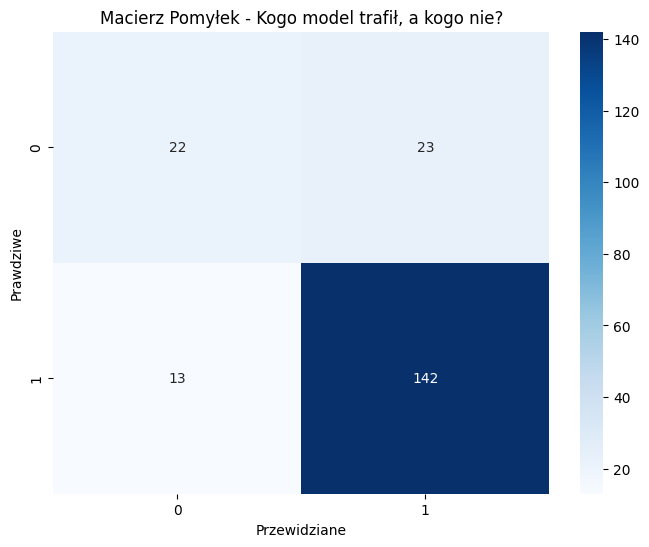

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Podział na cechy (X) i cel (y)
X = df_churn.drop('Odszedl', axis=1)
y = df_churn['Odszedl']

# 2. Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Trening modelu
model_churn = LogisticRegression()
model_churn.fit(X_train, y_train)

# 4. Predykcja
y_pred = model_churn.predict(X_test)

# 5. Wyświetlenie raportu skuteczności
print("Raport klasyfikacji:")
print(classification_report(y_test, y_pred))

# 6. Rysowanie Macierzy Pomyłek (Confusion Matrix)
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Przewidziane')
plt.ylabel('Prawdziwe')
plt.title('Macierz Pomyłek - Kogo model trafił, a kogo nie?')
plt.show()

--- RAPORT: RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.47      0.44      0.45        45
           1       0.84      0.85      0.85       155

    accuracy                           0.76       200
   macro avg       0.65      0.65      0.65       200
weighted avg       0.76      0.76      0.76       200



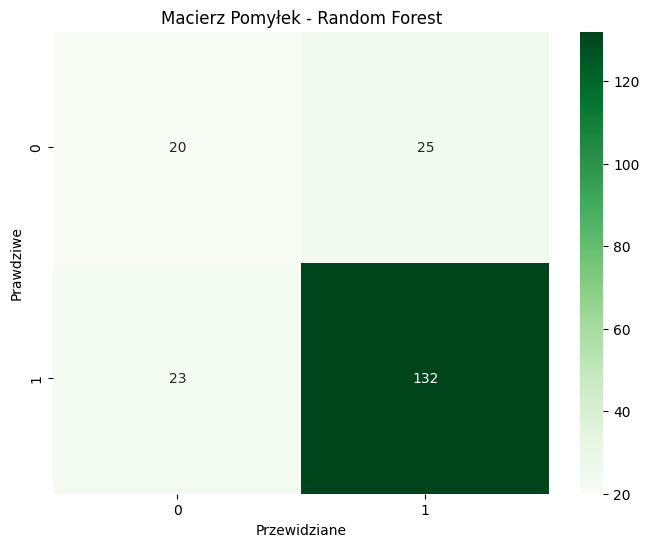


Co najbardziej wpływa na odejście klienta (według Lasu):
                          Cecha   Waznosc
1           Miesieczny_rachunek  0.322630
2               Miesiace_z_nami  0.273897
0                          Wiek  0.212641
3  Liczba_telefonow_do_supportu  0.190832


In [3]:
from sklearn.ensemble import RandomForestClassifier

# 1. Tworzymy model Lasu Losowego (100 drzew decyzyjnych)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Trenujemy model na tych samych danych
rf_model.fit(X_train, y_train)

# 3. Predykcja
y_pred_rf = rf_model.predict(X_test)

# 4. Wyświetlenie raportu
print("--- RAPORT: RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

# 5. Macierz pomyłek dla Lasu
plt.figure(figsize=(8,6))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens') # Zmienimy kolor na zielony dla odróżnienia
plt.xlabel('Przewidziane')
plt.ylabel('Prawdziwe')
plt.title('Macierz Pomyłek - Random Forest')
plt.show()

# 6. BONUS: Co było najważniejsze dla modelu?
importances = pd.DataFrame({
    'Cecha': X.columns,
    'Waznosc': rf_model.feature_importances_
}).sort_values(by='Waznosc', ascending=False)

print("\nCo najbardziej wpływa na odejście klienta (według Lasu):")
print(importances)